In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Форма выходных данных для одно и многоканальных картинок

In [4]:
images = torch.empty((10, 1, 16, 16)) # 10 single channel images
conv = nn.Conv2d(1, 4, kernel_size=3, padding=1)
conv(images).shape

torch.Size([10, 4, 16, 16])

In [5]:
images = torch.empty((10, 3, 16, 16)) # 10 three-channel images
conv = nn.Conv2d(3, 4, kernel_size=3, padding=1)
conv(images).shape

torch.Size([10, 4, 16, 16])

# Как работает Conv2d на многоканальном image?

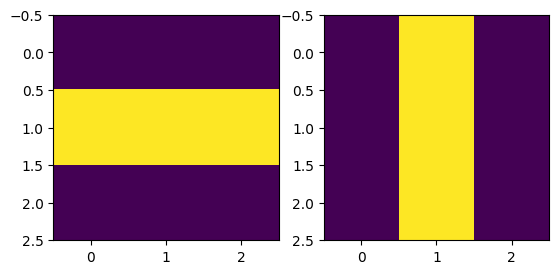

In [36]:
image = torch.zeros(2, 3, 3) # two-channel 3x3 image
image[0,1,:] = 1
image[1,:,1] = 1
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(image[0]);
ax2.imshow(image[1]);

In [48]:
images = image.reshape(1, *image.shape)
conv = nn.Conv2d(image.shape[0], 3, kernel_size=3, padding=0, bias=False)

In [39]:
v_list = []

for conv_layer_ind in range(conv.weight.shape[0]):
    v = 0
    
    for channel_ind in range(image.shape[0]):
        v += image[channel_ind].ravel() @ conv.weight[conv_layer_ind,channel_ind].ravel()

    v_list.append(v.item())

v_list = np.array(v_list)

In [40]:
a = conv(images).detach().numpy().ravel()
b = v_list
print(a, b)
assert np.all(np.isclose(a, b))

[ 0.10704701 -0.18643337  0.3280459 ] [ 0.10704702 -0.18643337  0.3280459 ]


- каждый из 3-х свёрточных слоев работает независимо от других
- каждый свёрточный слой содержит содержит 2 подслоя для кажого из каналов картинки
- подслои суммируются при свёртке

# Группы в Сonv2d

In [50]:
feature_maps = torch.zeros(32, 100, 100) # 32 feature maps 100x100
conv = nn.Conv2d(feature_maps.shape[0], 64, kernel_size=3, groups=1)
# Получаем 64 ядра, каждый из которых соединён с каждым им 32 feature_maps
conv.weight.shape

torch.Size([64, 32, 3, 3])

In [51]:
feature_maps = torch.zeros(32, 100, 100) # 32 feature maps 100x100
conv = nn.Conv2d(feature_maps.shape[0], 64, kernel_size=3, groups=2)
# Получаем 64 ядра, каждый из которых соединён с каким-то 16-ью из feature_maps
conv.weight.shape

torch.Size([64, 16, 3, 3])

In [52]:
feature_maps = torch.zeros(32, 100, 100) # 32 feature maps 100x100
conv = nn.Conv2d(feature_maps.shape[0], 64, kernel_size=3, groups=16)
# Получаем 64 ядра, каждый из которых соединён с каким-то 2-мя из feature_maps
conv.weight.shape

torch.Size([64, 2, 3, 3])